In [26]:
import earthaccess
import pyarrow.parquet as pq
import datetime
import matplotlib.pyplot as plt
import cartopy
import xarray as xr
import numpy as np
import pandas as pd
import statsmodels.api as sm

# This contains the path to the CrocoLake BGC-Argo dataset
# Update this file path if using a local copy
from setup import parquet_dir

# PACE match-up functions
from pace_matchup_fxns import get_sat_ts_matchups

# Get BGC-Argo matchups in the North Atlantic

Get all profiles in the North Atlantic in the last 180 days

In [27]:
# Time filter
# time1 = datetime.datetime.now()
time1 = datetime.datetime.strptime('2026-08-12', "%Y-%m-%d")
time0 = time1 - datetime.timedelta(days=180)

# Region filter
lat0 = 45
lat1 = 70
lon0 = -85
lon1 = 0

# Depth filter: Only want "surface" values
depth_min = 10

In [28]:
# Setting up parquet schema
BGC_schema = pq.read_schema(parquet_dir+"_common_metadata")

filter_coords_time = [
    ("JULD",">=",time0),
    ("LATITUDE",">",lat0), ("LATITUDE","<",lat1),
    ("LONGITUDE",">",lon0), ("LONGITUDE","<",lon1),
    ("PRES", "<", depth_min),
]

df = pq.ParquetDataset(parquet_dir, schema=BGC_schema, filters=filter_coords_time)
df = df.read().to_pandas()

In [29]:
variable_list = ['BBP700','BBP700_QC',  'CHLA','CHLA_QC',
                 'CYCLE_NUMBER',
                 'DOXY','DOXY_QC',
                 'JULD','LATITUDE','LONGITUDE',
                 'PLATFORM_NUMBER','PRES',
                 'PSAL','PSAL_QC',
                 'TEMP', 'TEMP_QC',]

surface_float = df.loc[:, variable_list].groupby(by = ['PLATFORM_NUMBER','CYCLE_NUMBER']).median()

In [30]:
# Get all non-NA surface bbp and chla
float_data = surface_float.loc[(surface_float.loc[:,'BBP700'].isna() == False) | \
    (surface_float.loc[:,'CHLA'].isna() == False),:]
float_data

BBP700  BBP700_QC     CHLA  CHLA_QC  \
PLATFORM_NUMBER CYCLE_NUMBER                                          
1902602         201           0.000361        1.0    0.162      5.0   
                202           0.000361        1.0   0.1728      5.0   
                203           0.000426        1.0    0.216      5.0   
                204           0.000428        1.0   0.2268      5.0   
                205           0.000459        1.0   0.2088      5.0   
...                                ...        ...      ...      ...   
7902223         68            0.000414        1.0  0.17885      5.0   
                69            0.000461        1.0   0.1606      5.0   
                70            0.000923        1.0   0.3066      5.0   
                71            0.000967        1.0  0.23725      5.0   
                72            0.001302        1.0   0.3504      5.0   

                                    DOXY  DOXY_QC  \
PLATFORM_NUMBER CYCLE_NUMBER                        
1902602         201           310.855682      1.0   
                202           310.826324      1.0   
                203           307.117981      1.0   
                204           309.205231      1.0   
                205           309.762817      1.0   
...                                  ...      ...   
7902223         68            272.904053      1.0   
                69            275.802094      1.0   
                70            285.449097      1.0   
                71            282.307556      1.0   
                72            284.986206      1.0   

                                                       JULD   LATITUDE  \
PLATFORM_NUMBER CYCLE_NUMBER                                             
1902602         201                     2026-02-13 11:31:00  64.796155   
                202                     2026-02-18 11:24:00  64.818238   
                203                     2026-02-23 11:26:00   64.84996   
                204                     2026-02-28 11:29:00  64.780737   
                205                     2026-03-05 11:24:00  64.762023   
...                                                     ...        ...   
7902223         68            2026-04-05 11:35:27.994887168  63.804615   
                69            2026-04-15 11:35:26.994713088  63.574452   
                70            2026-04-25 11:35:28.994884096  63.374601   
                71            2026-05-05 11:36:57.994770432   62.97507   
                72            2026-05-15 11:35:27.993174016  62.468869   

                              LONGITUDE   PRES       PSAL  PSAL_QC      TEMP  \
PLATFORM_NUMBER CYCLE_NUMBER                                                   
1902602         201           -4.435655   3.66     34.833      8.0     3.808   
                202           -4.468215   5.42  34.842999      8.0    3.6315   
                203           -4.526968   4.06  34.889999      8.0   4.04288   
                204            -4.62826    4.4  34.875999      8.0     3.762   
                205            -4.59849   4.15  34.867599      8.0    3.8158   
...                                 ...    ...        ...      ...       ...   
7902223         68           -30.148462   4.61     35.166      8.0  7.289898   
                69           -30.408009  3.632  35.143002      8.0    6.9631   
                70            -29.66107  3.632  35.150295      8.0  7.190845   
                71            -30.02976    3.9  35.190838      8.0  7.709755   
                72           -30.284667    4.2  35.170956      8.0  7.739409   

                              TEMP_QC  
PLATFORM_NUMBER CYCLE_NUMBER           
1902602         201               8.0  
                202               8.0  
                203               8.0  
                204               8.0  
                205               8.0  
...                               ...  
7902223         68                8.0  
                69                8.0  
              

Let's plot the values

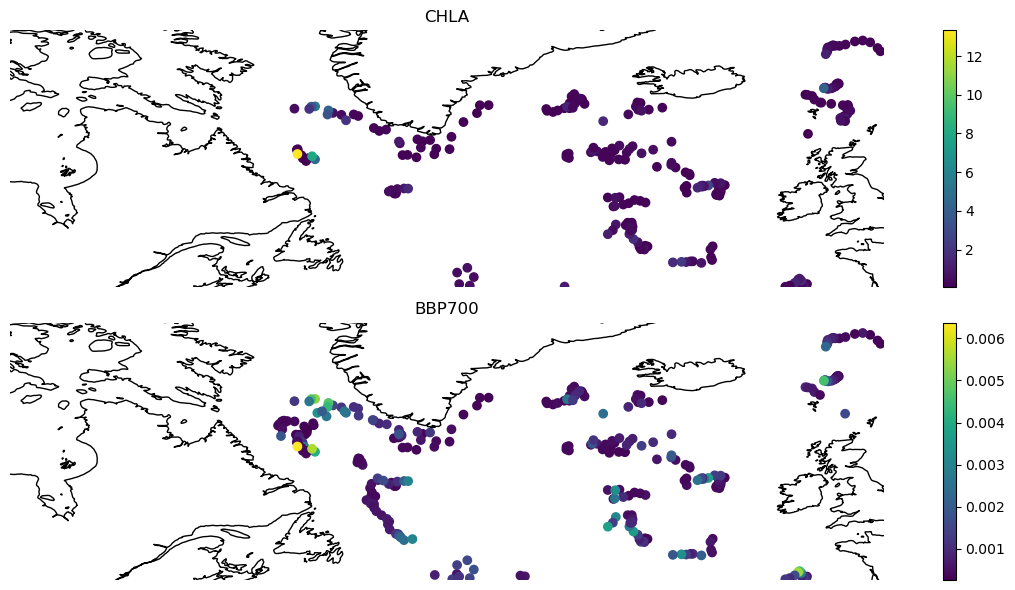

In [31]:
proj = cartopy.crs.PlateCarree()
fig = plt.figure(figsize=(12, 6), )
rr = 2; cc = 1

for pi, param in enumerate(['CHLA','BBP700']):
    
    ax = fig.add_subplot(rr, cc, int(pi+1), projection=proj, frameon=False)
    
    pcm = ax.scatter(float_data.loc[:,'LONGITUDE'], float_data.loc[:,'LATITUDE'], 
                c = float_data.loc[:,param])
    cbar = fig.colorbar(pcm, ax=ax)
    
    ax.add_feature(cartopy.feature.COASTLINE)

    ax.set_extent([lon0,lon1, lat0,lat1], crs = proj)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

    ax.set_title(param)


fig.tight_layout()

## Use Earthaccess to filter and download NASA Ocean Color data

- To use [earthaccess](https://earthaccess.readthedocs.io/en/stable/), you need to have a [NASA Earthdata Login](https://urs.earthdata.nasa.gov/)
- Need to provide username and passwork as a [.netrc](https://nsidc.org/data/user-resources/help-center/creating-netrc-file-earthdata-login) file saved in your JupyterHub directory (or on personal device) or as environmental variables.
- Need to run earthaccess.login() at the start of every session

In [32]:
earthaccess.login();

**Satellite: ocean color instrument**
- PACE: OCI (Ocean Color Instrument)
- Aqua: MODIS (Moderate Resolution Imaging Spectroradiometer) 

In [33]:
results = earthaccess.search_datasets(instrument="oci")

for item in results:
    summary = item.summary()
    print(summary["short-name"])

PACE_OCI_MI_CLOSE
PACE_OCI_L0_SCI
PACE_OCI_L1A_SCI
PACE_OCI_L1B_CLOSE
PACE_OCI_L1B_SCI
PACE_OCI_L1C_SCI
PACE_OCI_L2_UVAI_UAA_NRT
PACE_OCI_L2_UVAI_UAA
PACE_OCI_L2_AER_UAA_NRT
PACE_OCI_L2_AER_UAA
PACE_OCI_L2_AOP_NRT
PACE_OCI_L2_AOP
PACE_OCI_L2_CLOSE
PACE_OCI_L2_CLOUD_MASK_NRT
PACE_OCI_L2_CLOUD_MASK
PACE_OCI_L2_CLOUD_NRT
PACE_OCI_L2_CLOUD
PACE_OCI_L2_LANDVI_NRT
PACE_OCI_L2_LANDVI
PACE_OCI_L2_BGC_NRT
PACE_OCI_L2_BGC
PACE_OCI_L2_IOP_NRT
PACE_OCI_L2_IOP
PACE_OCI_L2_PAR_NRT
PACE_OCI_L2_PAR
PACE_OCI_L2_SFREFL_NRT
PACE_OCI_L2_SFREFL
PACE_OCI_L2_TRGAS_NRT
PACE_OCI_L2_TRGAS
PACE_OCI_L3B_CLOSE
PACE_OCI_L3B_LANDVI_NRT
PACE_OCI_L3B_LANDVI
PACE_OCI_L3B_SFREFL_NRT
PACE_OCI_L3B_SFREFL
PACE_OCI_L3M_UVAI_UAA_NRT
PACE_OCI_L3M_UVAI_UAA
PACE_OCI_L3M_AER_UAA_NRT
PACE_OCI_L3M_AER_UAA
PACE_OCI_L3M_AOP_NRT
PACE_OCI_L3M_AOP
PACE_OCI_L3M_CLOSE
PACE_OCI_L3M_CLOUD_MASK_NRT
PACE_OCI_L3M_CLOUD_MASK
PACE_OCI_L3M_CLOUD_NRT
PACE_OCI_L3M_CLOUD
PACE_OCI_L3M_KD_NRT
PACE_OCI_L3M_KD
PACE_OCI_L3M_LANDVI_NRT
PACE_OCI_L3M_LANDV

/var/folders/lj/ln2kqf0x2k795vs_453ytwp00000gn/T/ipykernel_29400/2542159695.py:4: FutureWarning: As of version 1.0, `DataCollection.summary` will be accessed as an attribute; e.g. use `DataCollection.summary` **not** `DataCollection.summary()`
  summary = item.summary()
/var/folders/lj/ln2kqf0x2k795vs_453ytwp00000gn/T/ipykernel_29400/2542159695.py:4: FutureWarning: As of version 1.0, `DataCollection.summary` will be accessed as an attribute; e.g. use `DataCollection.summary` **not** `DataCollection.summary()`
  summary = item.summary()
/var/folders/lj/ln2kqf0x2k795vs_453ytwp00000gn/T/ipykernel_29400/2542159695.py:4: FutureWarning: As of version 1.0, `DataCollection.summary` will be accessed as an attribute; e.g. use `DataCollection.summary` **not** `DataCollection.summary()`
  summary = item.summary()
/var/folders/lj/ln2kqf0x2k795vs_453ytwp00000gn/T/ipykernel_29400/2542159695.py:4: FutureWarning: As of version 1.0, `DataCollection.summary` will be accessed as an attribute; e.g. use `Da

In [34]:
short_name = 'PACE_OCI_L2_BGC'

tspan = (time0.strftime('%Y-%m-%d'), time1.strftime('%Y-%m-%d'))
bbox = (lon0, lat0, lon1, lat1)
clouds = (0, 50)

results = earthaccess.search_data(
    short_name = short_name,
    temporal=tspan,
    bounding_box=bbox,
    cloud_cover=clouds,
)
len(results)

/Users/epark/opt/anaconda3/envs/gobgc26/lib/python3.14/site-packages/earthaccess/results.py:348: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()


63

In [35]:
paths = earthaccess.open(results)

/Users/epark/opt/anaconda3/envs/gobgc26/lib/python3.14/site-packages/earthaccess/store.py:523: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum([granule.size() for granule in granules]) / 1024, 2)


QUEUEING TASKS | :   0%|          | 0/63 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/63 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/63 [00:00<?, ?it/s]

Open one of these files using xr.open_dataset...Note how there are no data variables, only attributes

In [36]:
fi = 3
dataset = xr.open_dataset(paths[fi])
dataset

<xarray.Dataset> Size: 0B
Dimensions:  ()
Data variables:
    *empty*
Attributes: (12/47)
    title:                             OCI Level-2 Data BGC
    product_name:                      PACE_OCI.20260222T115438.L2.OC_BGC.V3_...
    processing_version:                3.2
    history:                           l2gen par=/data3/sdpsoper/vdc/vpu23/wo...
    instrument:                        OCI
    platform:                          PACE
    ...                                ...
    geospatial_lon_min:                -12.175414
    startDirection:                    Ascending
    endDirection:                      Ascending
    day_night_flag:                    Day
    earth_sun_distance_correction:     1.0219511985778809
    geospatial_bounds:                 POLYGON((-3.00183 28.07932,24.50851 33...

In [37]:
dataset = xr.open_dataset(paths[fi], group  = 'geophysical_data')
dataset[['chlor_a', 'carbon_phyto', 'pic', 'poc', 'chlor_a_unc', 'carbon_phyto_unc']].to_array().values.shape

(6, 1710, 1272)

Each file is actually a group of Datasets
(1710, 1272, 172)

In [38]:
datatree = xr.open_datatree(paths[fi])
datatree

<xarray.DataTree>
Group: /
│   Attributes: (12/47)
│       title:                             OCI Level-2 Data BGC
│       product_name:                      PACE_OCI.20260222T115438.L2.OC_BGC.V3_...
│       processing_version:                3.2
│       history:                           l2gen par=/data3/sdpsoper/vdc/vpu23/wo...
│       instrument:                        OCI
│       platform:                          PACE
│       ...                                ...
│       geospatial_lon_min:                -12.175414
│       startDirection:                    Ascending
│       endDirection:                      Ascending
│       day_night_flag:                    Day
│       earth_sun_distance_correction:     1.0219511985778809
│       geospatial_bounds:                 POLYGON((-3.00183 28.07932,24.50851 33...
├── Group: /sensor_band_parameters
│       Dimensions:      (wavelength: 286, number_of_reflective_bands: 286)
│       Coordinates:
│         * wavelength   (wavelength) float64 2kB 315.0 316.0 ... 2.131e+03 2.258e+03
│       Dimensions without coordinates: number_of_reflective_bands
│       Data variables:
│           fwave        (wavelength) float32 1kB ...
│           vcal_gain    (number_of_reflective_bands) float32 1kB ...
│           vcal_offset  (number_of_reflective_bands) float32 1kB ...
│           F0           (number_of_reflective_bands) float32 1kB ...
│           aw           (number_of_reflective_bands) float32 1kB ...
│           bbw          (number_of_reflective_bands) float32 1kB ...
│           k_oz         (number_of_reflective_bands) float32 1kB ...
│           k_no2        (number_of_reflective_bands) float32 1kB ...
│           Tau_r        (number_of_reflective_bands) float32 1kB ...
├── Group: /scan_line_attributes
│       Dimensions:  (number_of_lines: 1710)
│       Dimensions without coordinates: number_of_lines
│       Data variables: (12/13)
│           year     (number_of_lines) float64 14kB ...
│           day      (number_of_lines) int64 14kB ...
│           msec     (number_of_lines) int64 14kB ...
│           time     (number_of_lines) datetime64[ns] 14kB ...
│           detnum   (number_of_lines) float32 7kB ...
│           mside    (number_of_lines) float32 7kB ...
│           ...       ...
│           clon     (number_of_lines) float32 7kB ...
│           elon     (number_of_lines) float32 7kB ...
│           slat     (number_of_lines) float32 7kB ...
│           clat     (number_of_lines) float32 7kB ...
│           elat     (number_of_lines) float32 7kB ...
│           csol_z   (number_of_lines) float32 7kB ...
├── Group: /geophysical_data
│       Dimensions:           (number_of_lines: 1710, pixels_per_line: 1272)
│       Dimensions without coordinates: number_of_lines, pixels_per_line
│       Data variables:
│           chlor_a           (number_of_lines, pixels_per_line) float32 9MB ...
│           carbon_phyto      (number_of_lines, pixels_per_line) float32 9MB ...
│           pic               (number_of_lines, pixels_per_line) float32 9MB ...
│           poc               (number_of_lines, pixels_per_line) float32 9MB ...
│           chlor_a_unc       (number_of_lines, pixels_per_line) float32 9MB ...
│           carbon_phyto_unc  (number_of_lines, pixels_per_line) float32 9MB ...
│           l2_flags          (number_of_lines, pixels_per_line) int32 9MB ...
├── Group: /navigation_data
│       Dimensions:    (number_of_lines: 1710, pixels_per_line: 1272)
│       Dimensions without coordinates: number_of_lines, pixels_per_line
│       Data variables:
│           longitude  (number_of_lines, pixels_per_line) float32 9MB ...
│           latitude   (number_of_lines, pixels_per_line) float32 9MB ...
│           tilt       (number_of_lines) float32 7kB ...
│       Attributes:
│           gringpointlongitude:  [ -3.001825  24.508512  23.462442 -12.175414]
│           gringpointlatitude:   [28.079315 33.478924 51.273556 45.04916 ]
│           gringpointsequence:   [1 2 3 4]
└─

Can merge all datasets into one

In [39]:
dataset = xr.merge(datatree.to_dict().values())
dataset

<xarray.Dataset> Size: 78MB
Dimensions:           (wavelength: 286, number_of_reflective_bands: 286,
                       number_of_lines: 1710, pixels_per_line: 1272)
Coordinates:
  * wavelength        (wavelength) float64 2kB 315.0 316.0 ... 2.258e+03
Dimensions without coordinates: number_of_reflective_bands, number_of_lines,
                                pixels_per_line
Data variables: (12/32)
    fwave             (wavelength) float32 1kB ...
    vcal_gain         (number_of_reflective_bands) float32 1kB ...
    vcal_offset       (number_of_reflective_bands) float32 1kB ...
    F0                (number_of_reflective_bands) float32 1kB ...
    aw                (number_of_reflective_bands) float32 1kB ...
    bbw               (number_of_reflective_bands) float32 1kB ...
    ...                ...
    chlor_a_unc       (number_of_lines, pixels_per_line) float32 9MB ...
    carbon_phyto_unc  (number_of_lines, pixels_per_line) float32 9MB ...
    l2_flags          (number_of_lines, pixels_per_line) int32 9MB ...
    longitude         (number_of_lines, pixels_per_line) float32 9MB ...
    latitude          (number_of_lines, pixels_per_line) float32 9MB ...
    tilt              (number_of_lines) float32 7kB ...
Attributes: (12/47)
    title:                             OCI Level-2 Data BGC
    product_name:                      PACE_OCI.20260222T115438.L2.OC_BGC.V3_...
    processing_version:                3.2
    history:                           l2gen par=/data3/sdpsoper/vdc/vpu23/wo...
    instrument:                        OCI
    platform:                          PACE
    ...                                ...
    geospatial_lon_min:                -12.175414
    startDirection:                    Ascending
    endDirection:                      Ascending
    day_night_flag:                    Day
    earth_sun_distance_correction:     1.0219511985778809
    geospatial_bounds:                 POLYGON((-3.00183 28.07932,24.50851 33...

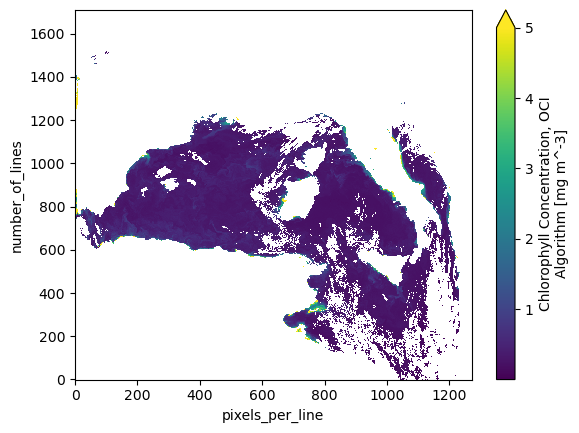

In [40]:
artist = dataset["chlor_a"].plot(vmax = 5)

## Matchup float profiles to NASA PACE BGC data

The following code has been modified from [PACE Hackweek tutorials](https://pacehackweek.github.io/pace-2025/presentations/notebooks/satellite_insitu_matchups.html) to be more generalized (from L2 AOP/Rrs to include L2 BGC, etc.)

This takes awhile (~1hr) to run for 318 profiles matched to 664 granuales! Here I will just show an example of a short matchup, and we will load pre-run output for this tutorial.

In [41]:
def FloatMatchup(float_data, sat_type, hour_window = 12, save = False, savename = 'PACE_BGCArgo_matchup.csv'):

    for i in np.arange(float_data.shape[0]):
    
        print('\nProfile count', i,' out of ', float_data.shape[0])
        prof_date = float_data.loc[:,'JULD'].values[i]
        start_date  = str(prof_date-np.timedelta64(hour_window,'h'))
        end_date = str(prof_date+np.timedelta64(hour_window,'h'))
        
        longitude = float_data.loc[:,'LONGITUDE'].values[i]
        latitude = float_data.loc[:,'LATITUDE'].values[i]
    
        print('All granuales withing +/- '+str(hour_window)+' hours of ',prof_date)
        print('at ', latitude,'ºN and ', longitude,'ºE')
    
        sat_values = get_sat_ts_matchups(start_date, end_date,latitude, longitude,
                            sat=sat_type)
    
        wmo, profnum = float_data.index.values[i]
        sat_values = sat_values.assign(PLATFORM_NUMBER =  np.ones(sat_values.shape[0], dtype = int)*wmo)
        sat_values = sat_values.assign(CYCLE_NUMBER =  np.ones(sat_values.shape[0], dtype = int)*profnum)
        
        if i == 0:
            all_sat = sat_values
        else:
            all_sat = pd.concat((all_sat, sat_values))
    
    all_sat = all_sat.reset_index(drop=True)

    if save:
        all_sat.to_csv(savename)

    return all_sat

In [42]:
all_sat = FloatMatchup(float_data, "PACE_BGC", hour_window = 12, save = True, savename = 'PACE_BGCArgo_matchup.csv')


Profile count 0  out of  338
All granuales withing +/- 12 hours of  2026-02-13 11:31:00
at  64.796155 ºN and  -4.435655 ºE


/Users/epark/opt/anaconda3/envs/gobgc26/lib/python3.14/site-packages/earthaccess/results.py:348: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()
/Users/epark/opt/anaconda3/envs/gobgc26/lib/python3.14/site-packages/earthaccess/store.py:523: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum([granule.size() for granule in granules]) / 1024, 2)


QUEUEING TASKS | :   0%|          | 0/3 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/3 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/3 [00:00<?, ?it/s]

...

/Users/epark/opt/anaconda3/envs/gobgc26/lib/python3.14/site-packages/earthaccess/results.py:348: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()
/Users/epark/opt/anaconda3/envs/gobgc26/lib/python3.14/site-packages/earthaccess/store.py:523: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum([granule.size() for granule in granules]) / 1024, 2)


QUEUEING TASKS | :   0%|          | 0/4 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/4 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/4 [00:00<?, ?it/s]

Running Granule: 2026-05-15 05:40:58+00:00
Running Granule: 2026-05-15 12:04:16+00:00
Running Granule: 2026-05-15 13:42:35+00:00
Running Granule: 2026-05-15 15:15:54+00:00


## Visualize match up results

In [54]:
valid_matchup = all_sat.loc[all_sat.loc[:,'sat_pixel_valid']>0,:]

float_matchup = np.zeros((valid_matchup.shape[0], 2))*np.nan

for i in np.arange(valid_matchup.shape[0]):

    wmo, profnum = valid_matchup.loc[:,['PLATFORM_NUMBER','CYCLE_NUMBER']].values[i,:]

    valid_float = float_data.loc[(wmo, profnum),:]
    valid_float = pd.to_numeric(valid_float, errors='coerce')
    
    float_matchup[i, 0] = valid_float.loc['CHLA']
    float_matchup[i, 1] = valid_float.loc['BBP700']
    

In [55]:
def bbp_poc(bbp, method='C12'):

    if method == 'C12':
        poc = 35422*bbp + (- 14.4)

    return poc

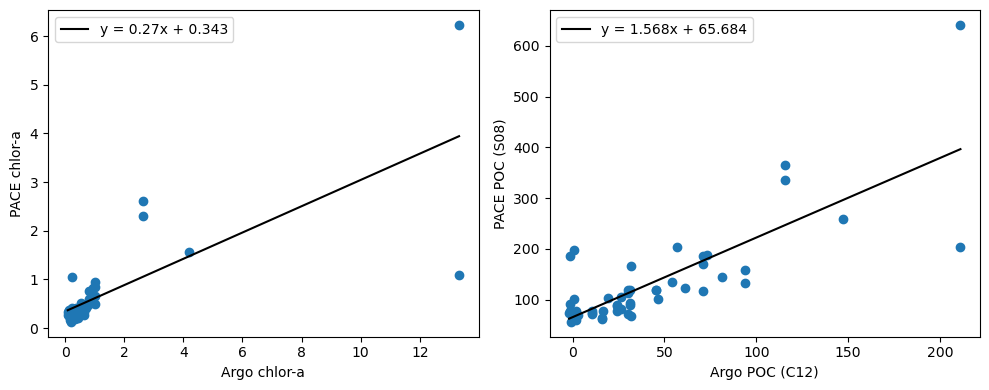

In [56]:
fig = plt.figure(figsize = (10, 4))
rr = 1; cc = 2

ax1 = fig.add_subplot(rr, cc,1)
ax2 = fig.add_subplot(rr, cc,2)

datalist = [[float_matchup[:,0],valid_matchup.loc[:,'sat_chlor_a'].values],
            [bbp_poc(float_matchup[:,1]), valid_matchup.loc[:,'sat_poc'].values]]
axlist = [ax1, ax2]
for i, xy in enumerate(datalist):

    x, y = xy
    ax = axlist[i]
    inds = np.where((np.isnan(x)==False) & (np.isnan(y)==False))
    x = x[inds]; y = y[inds]
    x_range = np.linspace(np.nanmin(x), np.nanmax(x))
    
    model = sm.OLS(y, sm.add_constant(x)).fit()
    
    eqn = 'y = '+str(np.round(model.params[1],3))+'x + '+str(np.round(model.params[0],3))
    
    ax.scatter(x, y)
    ax.plot(x_range, model.predict(sm.add_constant(x_range)), 'k-', label=eqn)
    ax.legend()

ax1.set_xlabel('Argo chlor-a')
ax1.set_ylabel('PACE chlor-a')

ax2.set_xlabel('Argo POC (C12)')
ax2.set_ylabel('PACE POC (S08)')

fig.tight_layout()

## Highlight other PACE products?
## CAFE-NPP, MOANA

In [49]:
type(valid_float.loc['CHLA'])

pandas.api.typing.NAType

In [53]:
pd.to_numeric(valid_float, errors='coerce')

BBP700        0.000484
BBP700_QC     1.000000
CHLA               NaN
CHLA_QC            NaN
DOXY               NaN
DOXY_QC            NaN
JULD               NaN
LATITUDE     59.648258
LONGITUDE   -58.525661
PRES          4.100000
PSAL         34.813999
PSAL_QC       8.000000
TEMP          3.970538
TEMP_QC       8.000000
Name: (4902684, 176), dtype: float64